<div align="center">
  <h1><b> Quantum Computing </b></h1>
  <h2> Quantum Algorithms </h2>
  <h3> ADAPT-VQE </h3>
</div>

</br>
<b>Author:</b> <a target="_blank" href="https://github.com/camponogaraviera">Lucas Camponogara Viera</a>

# Table of Contents

- [Introduction](#introduction)

<div style="margin-top:2px;"></div>

- [Algorithm Outline](#algorithm-outline)

<div style="margin-top:2px;"></div>

- [Qiskit Implementation](#qiskit-implementation)
  - Qiskit Version 
  - Importing Modules
  - get_qubit_op() Function
  - exact_energy_solution() Function
  - build_ansatz() Function
  - get_transpiled_circuit_depth() Function
  - run_adapt_vqe() Function
  - LiH Simulation

# Introduction

Most widely considered hardware-efficient and Chemistry-inspired ansatze, although generic, suffer from either barren plateaus [[1](https://www.nature.com/articles/s41467-018-07090-4)] or inconsistency under low-order trotterization steps [[2](https://pubs.acs.org/doi/abs/10.1021/acs.jctc.9b01083)], respectively. In order to circumvent this drawback, different algorithms for optimization of variational quantum circuits, the so-called adaptive circuits, have already been proposed in the literature. 

One example is the Adaptive Derivative-Assembled Pseudo-Trotter ansatz Variational Quantum Eigensolver (ADAPT-VQE) [[3](https://www.nature.com/articles/s41467-019-10988-2)]. In a nutshell, the ADAPT-VQE approach grows the ansatz by adding one fermionic operator at a time, such that the amount of correlation energy is recovered at each step.

However, ADAPT-VQE can be trapped in local minima and may suffer from over-parameterization.

# Algorithm Outline

1. On classical hardware, compute the second-quantized electronic Hamiltonian in a chosen basis set (e.g., STO-3G).

2. Map the fermionic Hamiltonian given in terms of its fermionic operators into a spin qubit-equivalent Hamiltonian using either `Bravyi-Kitaev`, `Jordan-Wigner`, or `Parity mapping` transformation. This is required to perform gate-based quantum computation. The number of qubits is required to obtain the electronic excitations and to build the quantum circuit. 
   
3. Obtain single and double electronic excitation operators by acting with the electron annihilation and creation operators on the Hartree-Fock reference state. 

4. Define an operator pool with all unique single and double excitation operators to create the corresponding SO(2) unitary qubit gates (the particular Givens rotations) to build a quantum circuit ansatz of particle-conserving unitary qubit gates.

5. Prepare an empty quantum circuit (ansatz) and initialize its qubits to a Hartree-Fock reference state. Add the previous qubit gates to the ansatz.
   
6. Initialize the parameter values of each gate in the ansatz to zero, i.e, initialize the ansatz to the identity matrix to compute the gradients with respect to the Hartree-Fock state.
    
7. Define the cost function as the expectation value of the qubit Hamiltonian. 

8. Define a classical optimizer (gradient-based or gradient-free) to update circuit parameters. If the optimizer is gradient-based, use the parameter shift rule to compute the gradient of the cost function with respect to its parameters.

9. On quantum hardware, initialize the trial state using the current ansatz.

10. For the current state, compute gradients for all operators in the pool.

11. Exit the loop when the norm of the gradient vector falls below a specified threshold, $\epsilon$. 
    
12. Select the operator with the largest gradient in magnitude.

13. Add the gate with the highest gradient to the left of the ansatz with a new variational parameter.

14. Re-optimize all parameters in the ansatz using traditional VQE with a classical optimizer.

15. Repeat from step 9 until convergence.

# Qiskit Implementation

## Qiskit Version

In [1]:
pip show qiskit qiskit-aer qiskit-nature qiskit-algorithms openfermion openfermionpyscf

Name: qiskit
Version: 2.2.3
Summary: An open-source SDK for working with quantum computers at the level of extended quantum circuits, operators, and primitives.
Home-page: https://www.ibm.com/quantum/qiskit
Author: 
Author-email: Qiskit Development Team <qiskit@us.ibm.com>
License: Apache 2.0
Location: /home/lucas/anaconda3/envs/qc-qiskit/lib/python3.11/site-packages
Requires: dill, numpy, rustworkx, scipy, stevedore, typing-extensions
Required-by: qiskit-aer, qiskit-algorithms, qiskit-ibm-runtime, qiskit-nature
---
Name: qiskit-aer
Version: 0.17.2
Summary: Aer - High performance simulators for Qiskit
Home-page: https://github.com/Qiskit/qiskit-aer
Author: AER Development Team
Author-email: qiskit@us.ibm.com
License: Apache 2.0
Location: /home/lucas/anaconda3/envs/qc-qiskit/lib/python3.11/site-packages
Requires: numpy, psutil, python-dateutil, qiskit, scipy
Required-by: 
---
Name: qiskit-nature
Version: 0.7.2
Summary: Qiskit Nature: A library of quantum computing chemistry/physics expe

## Importing Modules

In [2]:
# Type annotations:
from typing import List, Tuple, Union      
from qiskit.quantum_info.operators.symplectic.sparse_pauli_op import SparsePauliOp 
from qiskit_nature.second_q.problems.electronic_structure_problem import ElectronicStructureProblem
from qiskit_nature.second_q.operators.fermionic_op import FermionicOp
from qiskit.quantum_info.operators.symplectic.sparse_pauli_op import SparsePauliOp 
from qiskit_nature.second_q import mappers
from qiskit.circuit.library import EvolvedOperatorAnsatz
from qiskit import QuantumCircuit
from qiskit_algorithms import optimizers

# Qubit Operator:
from qiskit_nature.second_q.mappers import JordanWignerMapper, BravyiKitaevMapper, ParityMapper
from qiskit_nature.second_q.formats.molecule_info import MoleculeInfo
#from qiskit_nature.second_q.transformers import FreezeCoreTransformer
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_nature.second_q.drivers import PySCFDriver

# FCI:
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver

# Ansatz:
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock

# Transpiler:
from qiskit import transpile
from qiskit_aer import AerSimulator

# VQE, ADAPT-VQE:
from qiskit_algorithms.minimum_eigensolvers import AdaptVQE, VQE
from qiskit.primitives import StatevectorEstimator
import numpy as np
import copy

# Classical Optimizer:
from qiskit_algorithms.optimizers import SLSQP, L_BFGS_B, COBYLA

## get_qubit_op() Function

In [3]:
def get_qubit_op(
    symbols: List[str],
    coordinates: List[Tuple[float, float, float]],
    multiplicity: int,
    charge: int,
    basis: str,
    num_electrons: int,
    num_spatial_orbitals: int,
    mapper: Union[JordanWignerMapper, BravyiKitaevMapper, ParityMapper] = JordanWignerMapper(),
    molecule_name: str = "unknown",
) -> Tuple[ElectronicStructureProblem, FermionicOp, SparsePauliOp]:
    """
    Get the qubit-equivalent Hamiltonian of a particular molecule.

    Args:
        symbols: The chemical symbols of the atoms in the molecule. (e.g., ['H', 'H']).
        coordinates: The coordinates of the atoms in the molecule (e.g., [(0.0, 0.0, -dist), (0.0, 0.0, dist)]).
        multiplicity: The multiplicity of the molecule (2*spin + 1).
        charge: Total charge of the molecule (e.g., 0 for neutral).
        basis: The basis set to use for the molecular calculation (e.g., 'sto-3g').
        num_electrons_to_use: The number of electrons to use in the calculation.
        num_spatial_orbitals_to_use: The number of spatial orbitals to use in the calculation.
        mapper: The mapper to use for converting fermionic operators to qubit operators.
        molecule_name: The name of the molecule (for logging purposes).

    Returns:
        molecule: The electronic structure of the molecule.
        fermionic_hamiltonian: The fermionic Hamiltonian of the molecule in the 2nd quantization formalism.
        qubit_hamiltonian: The qubit-equivalent Hamiltonian of the molecule.
    """

    print(f"\nBuilding the qubit-equivalent Hamiltonian for the {molecule_name} molecule...")

    z2symmetry_reduction = None

    # Mol. info with coordinates in Angstrom:
    molecule_info = MoleculeInfo(
        symbols=symbols,
        coords=coordinates,
        multiplicity=multiplicity,
        charge=charge,
    )

    # Driver:
    driver = PySCFDriver.from_molecule(molecule_info, basis=basis)

    # Get the electronic structure of the molecule:
    molecule = driver.run()

    print('Num of alpha+beta spin electrons before reduction:', molecule.num_alpha + molecule.num_beta)
    print('Num of spatial orbitals before reduction:', molecule.num_spatial_orbitals)

    # Reduce the molecule size using ACTIVE space approximation:
    transformer = ActiveSpaceTransformer(
        num_electrons=num_electrons,
        num_spatial_orbitals=num_spatial_orbitals,
        active_orbitals=None
    )

    # Reduced electronic structure of the molecule:
    molecule  = transformer.transform(molecule)

    print('\nNum of alpha+beta spin electrons after reduction:', molecule.num_alpha + molecule.num_beta)
    print('Num of spatial orbitals after reduction:', molecule.num_spatial_orbitals)

    # Get the Fermionic Hamiltonian in the 2nd quantization formalism:
    fermionic_hamiltonian = molecule.second_q_ops()[0]

    # Get the qubit operator:
    qubit_hamiltonian = mapper.map(fermionic_hamiltonian)

    print("\nNum of qubits:", qubit_hamiltonian.num_qubits)

    # Apply symmetry:
    if z2symmetry_reduction != None:
        tapered_mapper = molecule.get_tapered_mapper(mapper)
        qubit_hamiltonian = tapered_mapper.map(fermionic_hamiltonian)

    return molecule, fermionic_hamiltonian, qubit_hamiltonian

## exact_energy_solution() Function

In [4]:
def exact_energy_solution(
    molecule: ElectronicStructureProblem, 
    qubit_hamiltonian: SparsePauliOp, 
    exact_solver = NumPyMinimumEigensolver()
):
    """
    Computes the exact ground state energy of a molecule.

    Args:
        molecule: The electronic structure of the molecule.
        qubit_hamiltonian: The qubit-equivalent Hamiltonian of the molecule.
        exact_solver: The exact solver to use for computing the minimum eigenvalue.

    Returns:
        fc_energy: The exact ground state energy of the molecule.
    """
    exact_result = exact_solver.compute_minimum_eigenvalue(qubit_hamiltonian)
    fc_energy = molecule.interpret(exact_result).total_energies[0].real
    return fc_energy

## build_ansatz() Function

In [5]:
def build_ansatz(
    num_spatial_orbitals: int, 
    num_particles: Tuple, 
    mapper: mappers, 
):    
    """
    Build the ansatz for a given molecule.

    Args:
        num_spatial_orbitals: Number of spatial orbitals in the molecule.
        num_particles: Number of particles in the molecule.
        mapper: The mapper used to convert the fermionic Hamiltonian to a qubit-equivalent Hamiltonian (e.g., "Jordan-Wigner").

    Returns:
        QuantumCircuit: The constructed ansatz.
    """
    
    init_state = HartreeFock(
        num_spatial_orbitals,
        num_particles,
        mapper,
    )    

    ansatz = UCCSD(num_spatial_orbitals, num_particles, mapper, initial_state=init_state, reps=1)

    return ansatz

## get_transpiled_circuit_depth() Function

In [6]:
def get_transpiled_circuit_depth(ansatz: QuantumCircuit) -> int:
    """
    Get the depth of the transpiled quantum circuit.

    Args:
        ansatz: The quantum circuit to be transpiled.

    Returns:
        depth: The depth of the transpiled quantum circuit.
    """
    backend = AerSimulator()
    param_dict = {p: 0.0 for p in ansatz.parameters}
    circuit = ansatz.decompose()
    circuit = circuit.assign_parameters(param_dict)
    transpiled_circuit = transpile(circuit, backend=backend, optimization_level=0)
    depth = transpiled_circuit.depth()
    return depth

## run_adapt_vqe() Function

In [7]:
def run_adapt_vqe(
    qubit_hamiltonian: SparsePauliOp,
    molecule: ElectronicStructureProblem, 
    ansatz: EvolvedOperatorAnsatz | QuantumCircuit, 
    optimizer: optimizers, 
    gradient_threshold: float,
    eigenvalue_threshold: float,
    max_iterations: int
):
    """
    This function wraps Qiskit's ADAPT-VQE implementation. 
    The operator pool is implicitly defined by the provided ansatz (e.g., UCCSD), 
    unless explicitly specified via the AdaptVQE `operators` argument (not used here).
    
    Args:
        qubit_hamiltonian: The qubit Hamiltonian for which to compute the ground state energy.
        molecule: The electronic structure of the molecule.
        ansatz: The variational form (ansatz) to use for the VQE algorithm.
        optimizer: The classical optimizer to use for the VQE algorithm (e.g., COBYLA, SLSQP).
        gradient_threshold: Exit the loop if the absolute value of each operator gradient is below this threshold. 
        eigenvalue_threshold: Exit the loop if the eigenvalue difference between two subsequent iterations is below this threshold. 
        max_iterations: The maximum number of ADAPT-VQE iterations.

    Returns:
        adapt_energy: The computed ground state energy from the ADAPT-VQE algorithm.
    """
    vqe = VQE(StatevectorEstimator(), ansatz=ansatz, optimizer=optimizer)
    
    adapt_vqe = AdaptVQE(
        vqe,
        gradient_threshold=gradient_threshold,
        eigenvalue_threshold=eigenvalue_threshold,
        max_iterations=max_iterations,
        operators = None, 
        reps=1,
        evolution=None,
        insert_barriers=False,
        name='EvolvedOps', 
        parameter_prefix='t',
        remove_identities=True, 
        initial_state=None,
        flatten=None
    )
    
    result = adapt_vqe.compute_minimum_eigenvalue(qubit_hamiltonian)
    energy = molecule.interpret(result).total_energies[0].real
    
    return energy, result

## LiH Simulation

### Get the Qubit Operator

In [8]:
eq_dist_ang = 1.59 # Equilibrium distance for LiH in Angstrom.

symbols = ["Li", "H"]
coordinates = ([0.0, 0.0, 0.0], [0.0, 0.0, eq_dist_ang])

multiplicity = 1
charge = 0
basis = "sto-3g"

num_electrons_to_use = 2        # Should be even. LiH has originally 4 electrons.
num_spatial_orbitals_to_use = 2 # LiH has originally 6 spatial orbitals.
num_particles = (1, 1)

mapper_name = "Jordan-Wigner"   # Options: "Bravyi-Kitaev", "Jordan-Wigner", or "Parity".
# Mapper:
match mapper_name:
    case "Jordan-Wigner":
        mapper = JordanWignerMapper()
    case "Bravyi-Kitaev":
        mapper = BravyiKitaevMapper()
    case "Parity":
        mapper = ParityMapper(num_particles=num_particles)

molecule, fermionic_hamiltonian, qubit_hamiltonian = get_qubit_op(
    symbols=symbols,
    coordinates=coordinates,
    multiplicity= multiplicity,
    charge = charge,
    basis = basis,
    num_electrons = num_electrons_to_use,
    num_spatial_orbitals = num_spatial_orbitals_to_use,
    mapper = mapper
)


Building the qubit-equivalent Hamiltonian for the unknown molecule...
Num of alpha+beta spin electrons before reduction: 4
Num of spatial orbitals before reduction: 6

Num of alpha+beta spin electrons after reduction: 2
Num of spatial orbitals after reduction: 2

Num of qubits: 4


### Compute Exact Energy

In [9]:
exact_energy = exact_energy_solution(molecule, qubit_hamiltonian)
print(f"Exact energy: {exact_energy}")

Exact energy: -7.862434137634505


### Run Adapt VQE

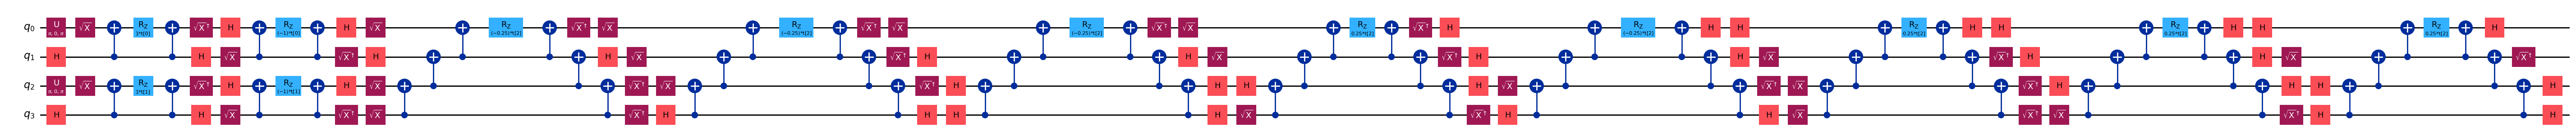


Circuit depth before transpilation: 83
Circuit depth after transpilation: 83
Number of parameters: 3


In [10]:
num_spatial_orbitals = molecule.num_spatial_orbitals
num_particles = molecule.num_particles

ansatz = build_ansatz(num_spatial_orbitals, num_particles, mapper)

display(ansatz.decompose().decompose().draw("mpl", fold=-1))
print(f"\nCircuit depth before transpilation: {ansatz.decompose().decompose().depth()}")
print(f"Circuit depth after transpilation: {get_transpiled_circuit_depth(ansatz)}")
print(f"Number of parameters: {len(ansatz.decompose().decompose().parameters)}")

In [15]:
optimizer = SLSQP(maxiter=200, disp=True, ftol=1e-10, tol=1e-10)

energy, result = run_adapt_vqe(
    qubit_hamiltonian = qubit_hamiltonian,
    molecule = molecule,
    ansatz = copy.deepcopy(ansatz),
    optimizer = optimizer,
    gradient_threshold = 1e-5,
    eigenvalue_threshold = 1e-6,
    max_iterations = 200
)

print(f"\nADAPT-VQE energy: {energy}")
print(f"Circuit depth after optimization: {result.optimal_circuit.decompose().decompose().depth()}")
print(f"Number of parameters: {len(ansatz.decompose().decompose().parameters)}")

Optimization terminated successfully    (Exit mode 0)
            Current function value: -1.0604916400682212
            Iterations: 3
            Function evaluations: 6
            Gradient evaluations: 3
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1.0604993661851605
            Iterations: 5
            Function evaluations: 15
            Gradient evaluations: 5
Optimization terminated successfully    (Exit mode 0)
            Current function value: -1.0605057471065966
            Iterations: 6
            Function evaluations: 24
            Gradient evaluations: 6

ADAPT-VQE energy: -7.862434137614283
Circuit depth after optimization: 83
Number of parameters: 3


- Original ansatz:

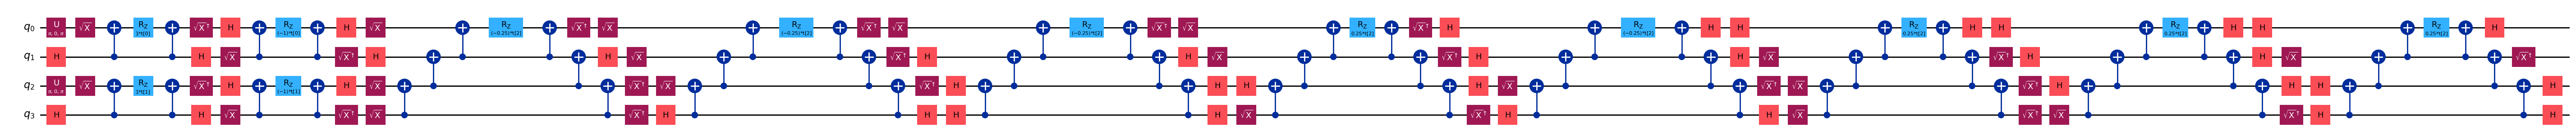

In [12]:
ansatz.decompose().decompose().draw("mpl", fold=-1)

- Optimized ansatz:

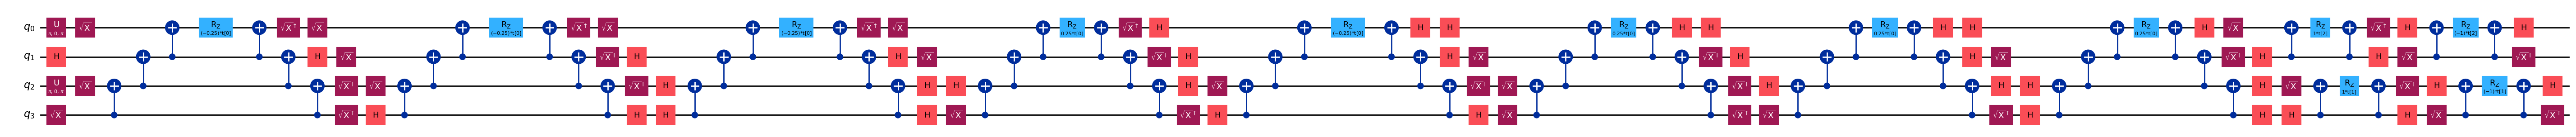

In [13]:
result.optimal_circuit.decompose().decompose().draw("mpl", fold=-1)

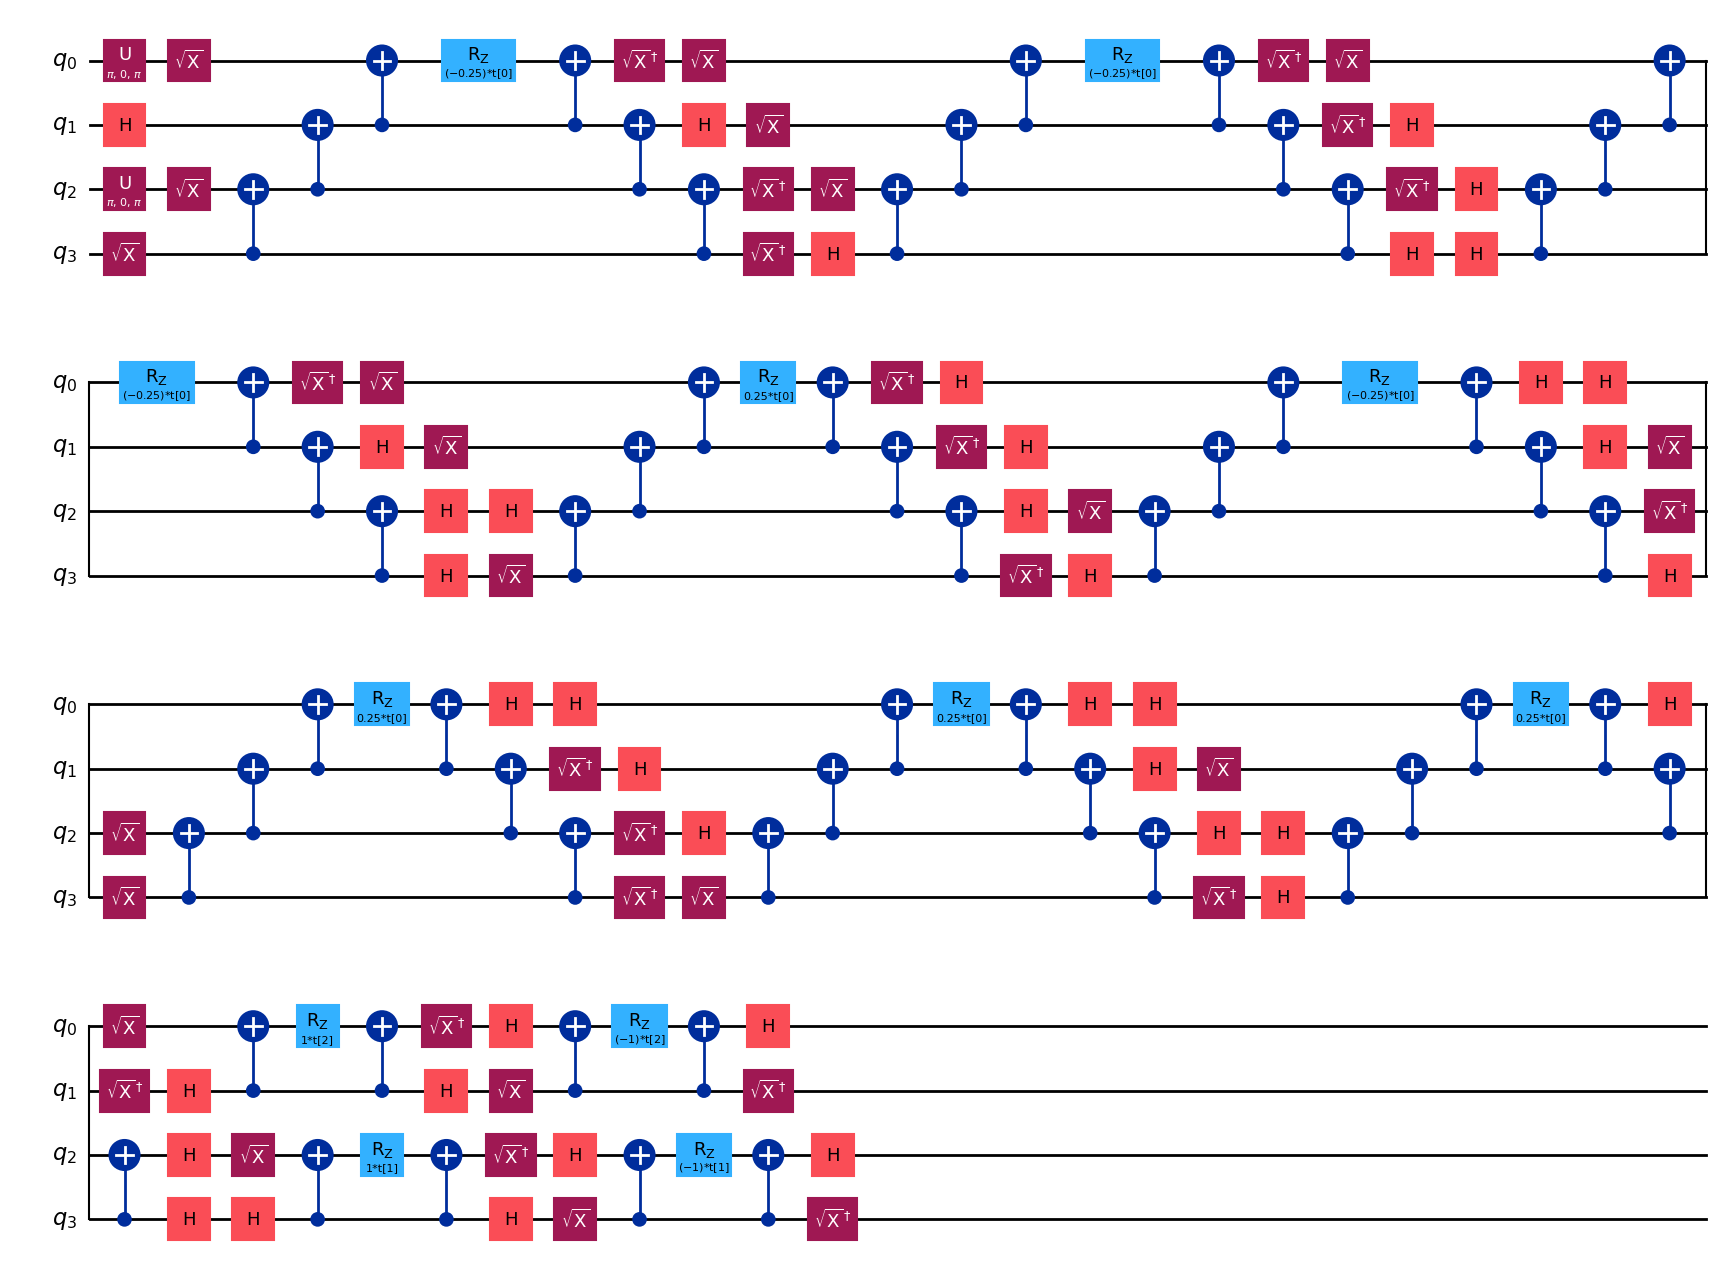

In [14]:
result.optimal_circuit.decompose().decompose().draw("mpl")

# &nbsp; <a href="#"><img valign="middle" height="45px" src="https://img.icons8.com/book" width="45" hspace="0px" vspace="0px"></a> References<a name="ref" />

[1] McClean, J.R., Boixo, S., Smelyanskiy, V.N. et al. Barren plateaus in quantum neural network training landscapes. [Nat Commun 9, 4812 (2018)](https://www.nature.com/articles/s41467-018-07090-4). 

[2] Grimsley, H. R.; Claudino, D.; Economou, S. E.; Barnes, E.; Mayhall, N. J. Is the trotterized uccsd ansatz chemically well-defined? [J. Chem. Theory Comput. 2020, 16, 1](https://pubs.acs.org/doi/abs/10.1021/acs.jctc.9b01083).

[3] Harper R. Grimsley, Sophia E. Economou, Edwin Barnes, Nicholas J. Mayhall, "An adaptive variational algorithm for exact molecular simulations on a quantum computer". [Nat. Commun. 2019, 10, 3007](https://www.nature.com/articles/s41467-019-10988-2).

[4] https://quantum.cloud.ibm.com/learning/en/courses/quantum-diagonalization-algorithms/vqe